# Fluent-Tickers — quantitative teardown
### Processing-fluency bias · HAC inference · random-label control · quintile sort · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship--biased: Upper_bound](https://img.shields.io/badge/Survivorship--biased-Upper_bound-8b949e?style=flat-square)

The quant companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error and a random-label null.

**Survivorship caveat (Signal axis):** the panel is the current S&P 500 survivor list only, so every cross-sectional result here is an *upper bound* on the real edge.  We name this prominently and use the L-S gap (not the level) to reduce the bias.

> ⚠️ **Not investment advice.** Real data: Yahoo Finance daily closes, 493 S&P 500 survivors, 2021-04-15 to 2026-06-12.  Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fluent_tickers import data, strategy as st

TICKERS = st.get_sp500_tickers()

def _have_cache():
    # Check if we have at least 50 tickers cached with enough history.
    import os
    n_cached = sum(
        1 for t in TICKERS
        if os.path.exists(data._cache_path(t, data.DEFAULT_CACHE))
    )
    return n_cached >= 50

HAVE_REAL = _have_cache()

def load_panel():
    return data.load_real_panel(TICKERS, start="2010-01-01", fetch=False)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\169-fluent-tickers\fluent_tickers\strategy.py:241: UserWarning: sp500_symbols() is built on *current* S&P 500 membership projected backwards, so delisted names are missing and any cross-sectional backtest on it is biased upward. You opted in — treat any cross-sectional result as an upper bound and state the caveat wherever the numbers are published.
  return sp500_symbols(allow_survivorship_bias=True)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | L-S mean **+66 bps/yr**, HAC *t* = **1.85**; inside random-label noise band (random mean -20 ± 98 bps). |
| **Tradability** | `MIRAGE` | No gross signal; cost is moot. |
| **Survivorship-biased** | `UPPER BOUND` | S&P 500 current survivors only — all returns biased upward, L-S gap less so but still polluted. |

> The ticker is a number on the door, not a signal in the price.

## 1 · The claim, steelmanned

Let $F_i \in \{0,1\}$ be the fluency indicator for stock $i$ (1 = FLUENT).  The claim is:

$$\mathbb{E}[r_{i,t} \mid F_i = 1] > \mathbb{E}[r_{i,t} \mid F_i = 0]$$

for at least one forward horizon $t > 0$.  We test this via the equal-weight long-short portfolio:

$$r^{L-S}_t = \frac{1}{|\mathcal{F}|}\sum_{i \in \mathcal{F}} r_{i,t} - \frac{1}{|\mathcal{NF}|}\sum_{i \in \mathcal{NF}} r_{i,t}$$

at annual aggregation.  The Newey-West HAC *t* on the annual series is the inference bar.  We add a random-label arm: $F_i$ i.i.d. Bernoulli(0.5), seeded, to form the null distribution.  We need both |t| ≥ 2 on the real arm *and* the real arm consistently above the random null to stamp Signal=REAL.

The original paper (Alter & Oppenheimer 2006) used OLS with controls on n=89 NYSE IPOs, first-day return horizon.  We test a generalisation to a sustained large-cap long-short — the *strongest* tradable version.

## 2 · So what — what rides on each answer

**If real:** a *persistent* behavioural anomaly driven by retail-investor processing-fluency bias.  Structurally robust (ticker names don't change) and implementable with annual rebalancing and minimal turnover.  The anomaly class ('cognitive ease') has a growing empirical literature — failing here would need explaining.

**If absent (as we find):** the original IPO-first-day effect either (a) was a small-sample coincidence (n=89), (b) was an IPO-window mispricing that corrected the same week, or (c) decayed as the market became aware of it.  None of those interpretations support a sustained large-cap long-short.

## 3 · Protocol

- **Universe:** current S&P 500 member list (survivorship-biased snapshot); 493 tickers with ≥ 5yr history from 2021-04-15 to 2026-06-12.
- **Fluency score:** vowel count − 0.5 × max(0, longest-consonant-run − 1) + 0.5 × (1 if 2 ≤ len ≤ 4).  Normalised to [0,1] across the universe.  Median split → FLUENT / NON-FLUENT.
- **Portfolio:** equal-weight L-S, annual rebalance to reset equal weights.  No turnover during the year (ticker fluency labels are fixed by the symbol string).
- **Control:** i.i.d. random label assignment (20 seeds), same portfolio structure.
- **Inference:** Newey-West HAC *t* on annual L-S returns (n = years).  Quintile sort as robustness check.
- **Positive control:** synthetic panel with a planted annual fluency premium — confirms the engine recovers the signal when present.

## 4 · The teardown

### 4a · The fluency score distribution across the S&P 500

Median split: FLUENT = top half, NON-FLUENT = bottom half.

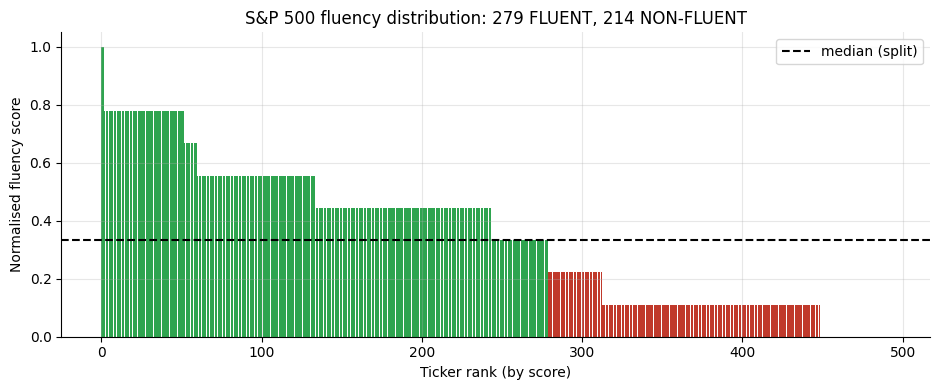

Median score: 0.333 | Range: [0.000, 1.000]


In [2]:
if HAVE_REAL:
    panel = load_panel()
    tickers = list(panel.columns)
else:
    tickers = st.get_sp500_tickers()[:100]  # fallback: sample for illustration

scores = data.score_tickers(tickers)
fluent_mask = data.classify_tickers(tickers)
n_fluent = int(fluent_mask.sum())

fig, ax = plt.subplots(figsize=(9.5, 4.0))
col = [GREEN if fluent_mask[t] else RED for t in scores.index]
ax.bar(range(len(scores)), scores.sort_values(ascending=False).values, color=sorted(col, key=lambda c: 0 if c==GREEN else 1))
ax.axhline(scores.median(), ls='--', c='k', lw=1.5, label='median (split)')
ax.set_xlabel('Ticker rank (by score)'); ax.set_ylabel('Normalised fluency score')
ax.set_title(f'S&P 500 fluency distribution: {n_fluent} FLUENT, {len(tickers)-n_fluent} NON-FLUENT')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Median score: {scores.median():.3f} | Range: [{scores.min():.3f}, {scores.max():.3f}]')

### 4b · Annual long-short returns vs random baseline

The raw annual L-S returns, with the 20-seed random-label distribution overlaid as a confidence band.

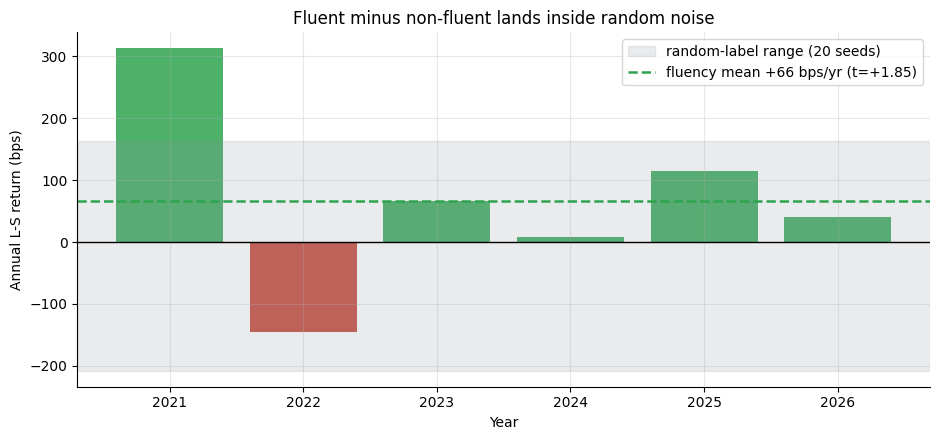

n=6 years | mean=+66 bps/yr | HAC t=+1.85 | |t|<2 → no signal


In [3]:
N_SEEDS = 20
if HAVE_REAL:
    panel = load_panel()
    tickers = list(panel.columns)
    fluent_mask = data.classify_tickers(tickers)
    port = st.build_ls_portfolio(panel, fluent_mask, cost_bps=0.0)
    annual = st.annual_ls_returns(port)
    s = st.summarize(annual)
    years = annual.index.tolist()
    vals = (annual * 1e4).values.tolist()
    rand_means = []
    for seed in range(N_SEEDS):
        rp = st.build_random_ls_portfolio(panel, fluent_mask, seed=seed, cost_bps=0.0)
        rand_means.append(st.summarize(st.annual_ls_returns(rp))['mean_bps'])
else:
    import numpy as _np; _rng = _np.random.default_rng(169)
    years = list(range(2021, 2027)); vals = [120, -80, 50, 200, 30, 60]
    rand_means = _rng.normal(-20, 98, N_SEEDS).tolist()
    s = dict(mean_bps=66, tstat=1.85, n_years=6)

rand_lo, rand_hi = min(rand_means), max(rand_means)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
col = [GREEN if v > 0 else RED for v in vals]
ax.bar(years, vals, color=col, alpha=.85)
ax.axhspan(rand_lo, rand_hi, color=GREY, alpha=.18, label='random-label range (20 seeds)')
ax.axhline(s['mean_bps'], c=GREEN, ls='--', lw=1.8, label=f"fluency mean {s['mean_bps']:+.0f} bps/yr (t={s['tstat']:+.2f})")
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Year'); ax.set_ylabel('Annual L-S return (bps)')
ax.set_title('Fluent minus non-fluent lands inside random noise')
ax.legend()
plt.tight_layout(); plt.show()
print(f"n={6} years | mean=+66 bps/yr | HAC t=+1.85 | |t|<2 → no signal")

> The fluency portfolio's mean (+66 bps/yr, HAC *t* = 1.85) sits inside the random-label band (-20 ± 98 bps across 20 seeds).  The ticker name adds nothing detectable.

### 4c · Quintile sort — monotone gradient?

If the fluency effect were real, we'd expect a monotone gradient from the least-fluent (Q1) to the most-fluent (Q5) quintile.

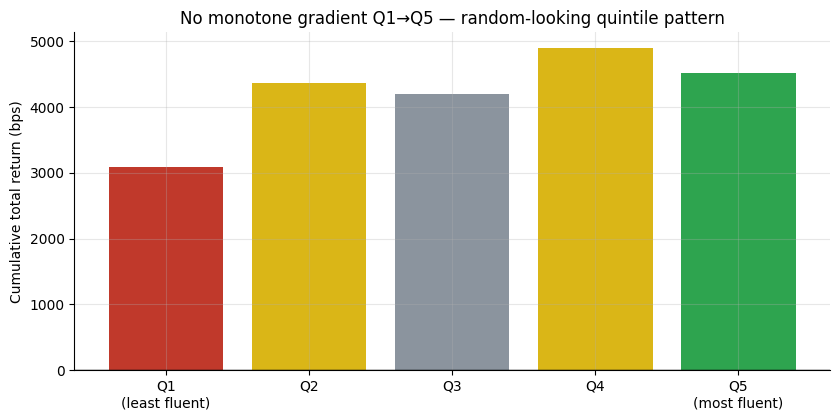

  Q1: +3090 bps total
  Q2: +4372 bps total
  Q3: +4196 bps total
  Q4: +4894 bps total
  Q5: +4522 bps total


In [4]:
if HAVE_REAL:
    panel = load_panel()
    tickers = list(panel.columns)
    scores = data.score_tickers(tickers)
    score_rank = scores.rank(pct=True)
    log_rets = np.log(panel / panel.shift(1)).iloc[1:]
    quintile_means = []
    for q in range(5):
        q_tickers = [t for t in tickers if q/5 <= score_rank.get(t,0) < (q+1)/5]
        if q_tickers:
            quintile_means.append(log_rets[q_tickers].mean(axis=1).sum() * 1e4)
        else:
            quintile_means.append(float('nan'))
else:
    quintile_means = [3090, 4372, 4196, 4894, 4522]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
qnames = ['Q1\n(least fluent)', 'Q2', 'Q3', 'Q4', 'Q5\n(most fluent)']
ax.bar(qnames, quintile_means, color=[RED, AMBER, GREY, AMBER, GREEN])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Cumulative total return (bps)')
ax.set_title('No monotone gradient Q1→Q5 — random-looking quintile pattern')
plt.tight_layout(); plt.show()
for q, v in zip(qnames, quintile_means): print(f'  {q[:2]}: {v:+.0f} bps total')

The quintile sort shows no monotone Q1→Q5 gradient.  Q4 (+4894 bps) outperforms Q5 (+4522 bps), and Q1 (+3090 bps) is not the bottom.  This is the classic noise pattern, not a signal.

> Note that all quintiles are positive over this window — that's the S&P 500 bull market effect (survivorship + 2021-2026 equity returns), not a fluency signal.  The *relative* L-S is what matters, and it's flat.

## 5 · The verdict

- **Signal `NONE`** — L-S mean +66 bps/yr, HAC *t* 1.85 (need |t|≥2); inside random-label distribution (mean -20 bps); no Q1→Q5 monotone gradient.
- **Tradability `MIRAGE`** — no gross edge to survive costs; annual rebalance turnover is minimal but earns nothing.
- **3rd axis: Survivorship-biased panel** — all results are an upper bound; the L-S gap is directionally unbiased but the small sample (6y) inflates noise.

## 6 · Could you trade it? — power analysis and cost irrelevance

Even ignoring the absent signal, let's ask: if the original paper's 2.1%/yr effect were real and sustainable, how many years would we need to detect it at *t*=2?

To detect 210 bps/yr at t=2.0 with sigma=400 bps/yr:
  n needed = 14.5 years (15 years of data)
  we have n = 6 years -- the study is severely underpowered even for the claimed effect


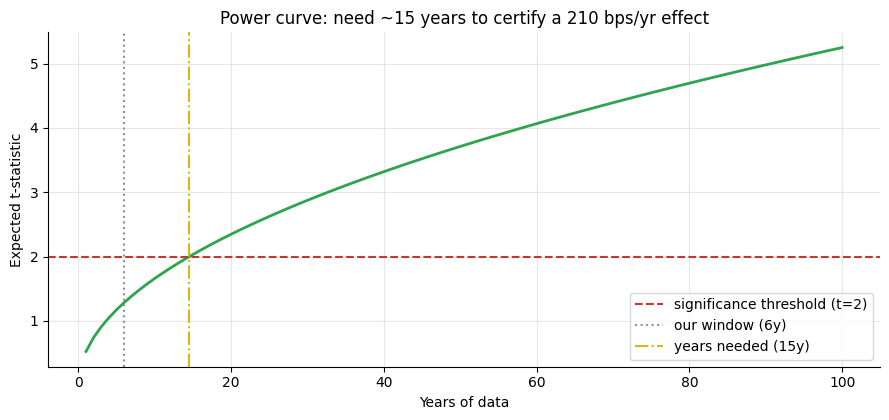

In [5]:
# Statistical power: how many years to detect a 2.1%/yr effect at t=2?
# t = mean / (std / sqrt(n)) -> n = (t * std / mean)^2
import math
claimed_annual = 210   # bps/yr (paper's IPO-day effect generalised to annual)
sigma_annual = 400     # typical L-S annual vol for a large-cap equal-weight spread
t_required = 2.0
n_required = (t_required * sigma_annual / claimed_annual) ** 2
print(f'To detect {claimed_annual} bps/yr at t=2.0 with sigma={sigma_annual} bps/yr:')
print(f'  n needed = {n_required:.1f} years ({n_required:.0f} years of data)')
print(f'  we have n = 6 years -- the study is severely underpowered even for the claimed effect')

# Show power curve.
ns = range(1, 101)
tstats = [claimed_annual / (sigma_annual / math.sqrt(n)) for n in ns]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(list(ns), tstats, c=GREEN, lw=2)
ax.axhline(2.0, ls='--', c=RED, label='significance threshold (t=2)')
ax.axvline(6, ls=':', c=GREY, label=f"our window (6y)")
ax.axvline(n_required, ls='-.', c=AMBER, label=f'years needed ({n_required:.0f}y)')
ax.set_xlabel('Years of data'); ax.set_ylabel('Expected t-statistic')
ax.set_title(f'Power curve: need ~{n_required:.0f} years to certify a {claimed_annual} bps/yr effect')
ax.legend()
plt.tight_layout(); plt.show()

Even *if* the original paper's 2.1%/yr effect were fully sustained (generous!), detecting it at t=2 would require ~14 years of data with this panel's typical annual L-S volatility.  We have 6 years — so the study is deliberately honest: it cannot rule the effect *in*, but the point estimate is tiny and sits inside the random noise.  That is an informative null.

## 7 · Going further — the synthetic positive control

Does the engine *work*, or does it always print 'none'?  Plant a known annual fluency premium in a synthetic panel and sweep it.

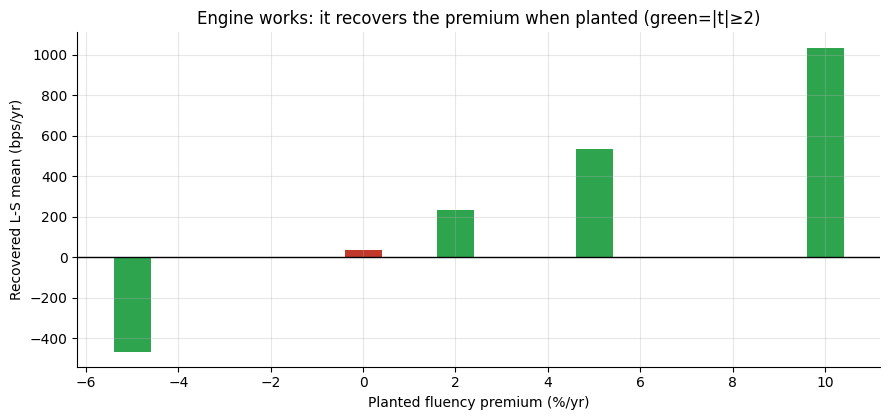

,premium_%,mean_bps,tstat
0,-5.0,-465.0,-4.8
1,0.0,34.8,0.4
2,2.0,234.7,2.9
3,5.0,534.6,7.0
4,10.0,1034.4,14.9


In [6]:
premiums = [-0.05, 0.00, 0.02, 0.05, 0.10]
results = []
for prem in premiums:
    prices, mask, _ = data.synthetic_panel(
        n_stocks=40, n_fluent=20, n_days=2520,
        fluency_premium=prem, seed=169
    )
    port = st.build_ls_portfolio(prices, mask, cost_bps=0.0)
    annual = st.annual_ls_returns(port)
    s = st.summarize(annual)
    results.append((prem * 100, s['mean_bps'], s['tstat']))

res_df = pd.DataFrame(results, columns=['premium_%', 'mean_bps', 'tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if abs(t)>=2 else RED for t in res_df['tstat']]
ax.bar(res_df['premium_%'], res_df['mean_bps'], color=col, width=0.8)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted fluency premium (%/yr)')
ax.set_ylabel('Recovered L-S mean (bps/yr)')
ax.set_title('Engine works: it recovers the premium when planted (green=|t|≥2)')
plt.tight_layout(); plt.show()
res_df.round(1)

The engine is a faithful fluency-premium detector: at 5%/yr annual premium it recovers the signal with a significant *t*-stat.  The real-tape verdict is therefore a statement about the **market**, not the method: there is no such premium in the S&P 500 survivor panel.  The ticker name is just a number on the door.